## Exercício

Considere $X \sim \mathrm{Binomial}(n,p)$. Gere uma amostra de tamanho $M$ pra cada item

1. Implemente a simulação de $X$ pelo método ingênuo, escrevendo $X$ como soma de $n$ variáveis aleatórias independentes com distribuição $\mathrm{Bernoulli}(p)$.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
#Importando bibliotecas
np.random.seed(847063) #Setando a seed


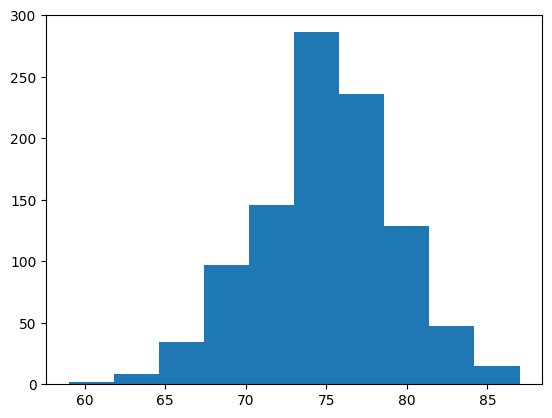

In [2]:
def bin(n, p, N):
  amostras = []
  for i in range(N):
    resultado = 0
    for j in range(n):
      if(np.random.uniform(low=0, high=1) < p):
        resultado += 1

    amostras.append(resultado)

  return amostras

dados = bin(100, 0.75, 1000)

plt.hist(dados)
plt.show()

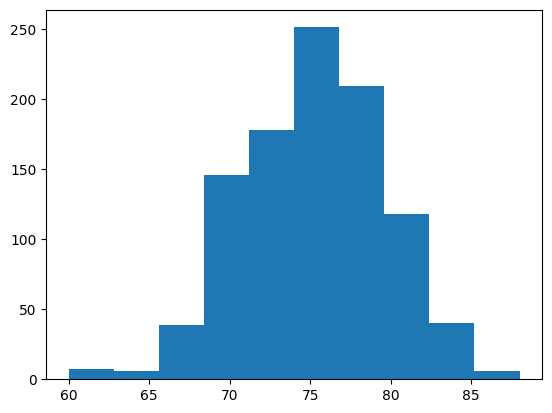

In [3]:
def binomial_otimizada(n, p, N):
  amostra = []
  for i in range(N):
    uniforme = np.random.uniform(low=0, high=1, size=n)
    valor = np.sum(uniforme <= p)
    amostra.append(valor)

  return amostra

dados_2 = binomial_otimizada(100, 0.75, 1000)

plt.hist(dados_2)
plt.show()

2. Implemente o método recursivo visto em sala:

   * Gere $U \sim U(0,1)$.

   * Inicialize $i=0$, $p_i=(1-p)^n$ e $F=p_i$.

   * Enquanto $U>F$, faça

     $$
     p_{i+1}=
     \frac{n-i}{i+1}
     \frac{p}{1-p}
     p_i,
     $$

     e atualize $i \leftarrow i+1$ e $F \leftarrow F+p_i$.

   * Retorne $X=i$.


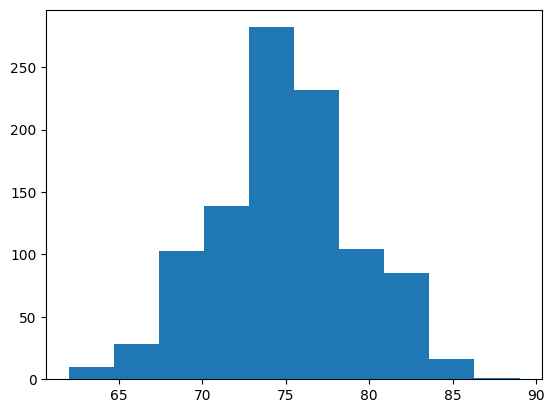

In [4]:
def binomial_recursiva(n, p, N):
  amostra = []
  for i in range(N):
    u = np.random.uniform(low=0, high=1)
    i = 0
    pi = (1-p)**n
    F = pi
    while u > F:
      pi = (n-i)/(i+1)*(p/(1-p))*pi
      i += 1
      F += pi
    amostra.append(i)
  return amostra

dados_3 = binomial_recursiva(100, 0.75, 1000)

plt.hist(dados_3)
plt.show()


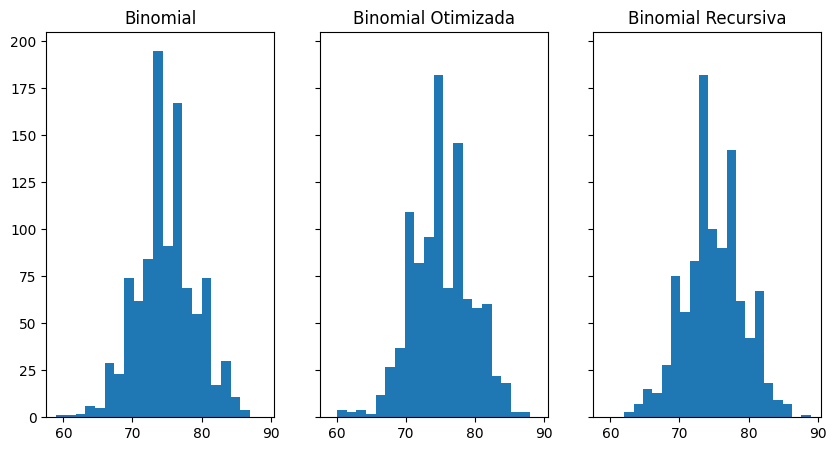

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(10, 5), sharex=True, sharey=True)
ax[0].hist(dados, bins=20)
ax[0].set_title("Binomial")
ax[1].hist(dados_2, bins=20)
ax[1].set_title("Binomial Otimizada")
ax[2].hist(dados_3, bins=20)
ax[2].set_title("Binomial Recursiva")

plt.show()

3. Use a função `np.linspace` para reproduzir os passos anteriores para diferentes valores de $p$ e $n$, compare o tempo de execução dos dois métodos. Para cada valor de $p$ e $n$, execute cada método 100 vezes e calcule a média dos tempos. Utilize `time.time()` para medir o tempo de execução de cada método.

4. Apresente os resultados em uma tabela ou gráfico e comente como o tempo de execução dos métodos varia com $p$.


100%|██████████| 100/100 [00:38<00:00,  2.60it/s]


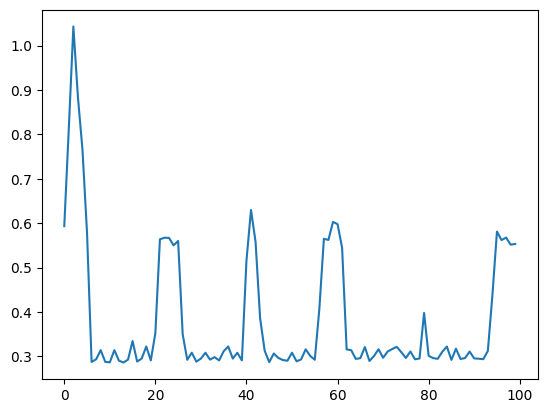

In [6]:
from tqdm import tqdm

tempo1_p = []
for p in tqdm(np.linspace(0, 1, 100)):
  comeco = time.time()
  tempo = bin(100, p, 1000)
  final = time.time()
  tempo1_p.append(final - comeco)

plt.plot(tempo1_p)
plt.show()

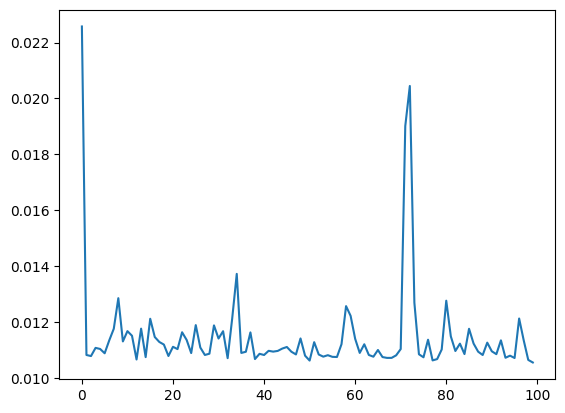

In [7]:
tempo2_p = []
for p in np.linspace(0, 1, 100):
  comeco = time.time()
  tempo = binomial_otimizada(100, p, 1000)
  final = time.time()
  tempo2_p.append(final - comeco)

plt.plot(tempo2_p)
plt.show()

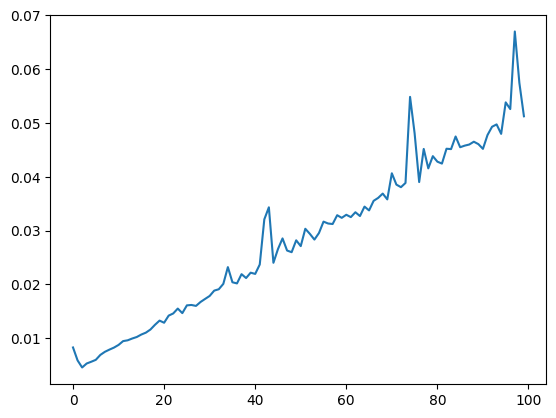

In [8]:
tempo3_p = []
for p in np.linspace(0, 0.99, 100):
  comeco = time.time()
  tempo = binomial_recursiva(100, p, 1000)
  final = time.time()
  tempo3_p.append(final-comeco)

plt.plot(tempo3_p)
plt.show()

In [9]:
medias_p = {
    "Bin": np.mean(tempo1_p),
    "Bin Otimizada": np.mean(tempo2_p),
    "Bin Recursiva": np.mean(tempo3_p)
}
print(medias_p) # Média do tempo de execução dos metodos conforme p varia

{'Bin': np.float64(0.3829426884651184), 'Bin Otimizada': np.float64(0.011468253135681152), 'Bin Recursiva': np.float64(0.028555841445922853)}


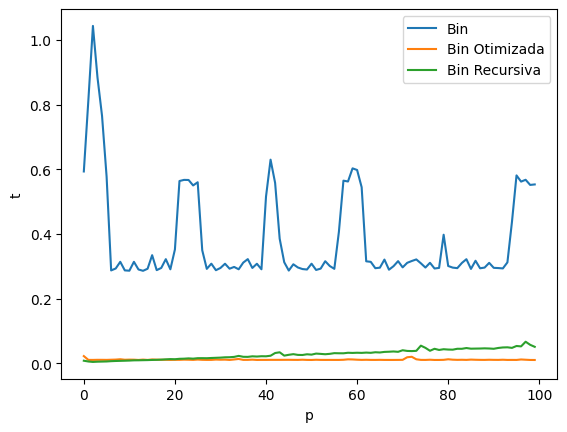

In [10]:
plt.plot(tempo1_p, label="Bin")
plt.plot(tempo2_p, label="Bin Otimizada")
plt.plot(tempo3_p, label="Bin Recursiva")

plt.ylabel("t")
plt.xlabel("p")
plt.legend()
plt.show()

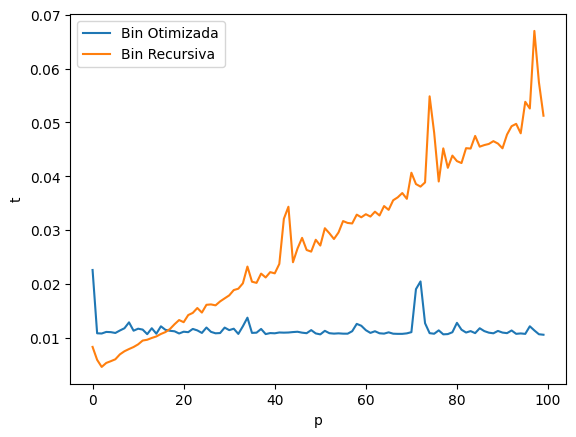

In [11]:
plt.plot(tempo2_p, label="Bin Otimizada")
plt.plot(tempo3_p, label="Bin Recursiva")

plt.ylabel("t")
plt.xlabel("p")

plt.legend()
plt.show()

No metodo Otimizado o tempo de execução se manteve meio constante independentemente de p. Já no metodo recursivo o tempo de execução aumenta conforme p aumenta.

100%|██████████| 101/101 [00:16<00:00,  6.05it/s]


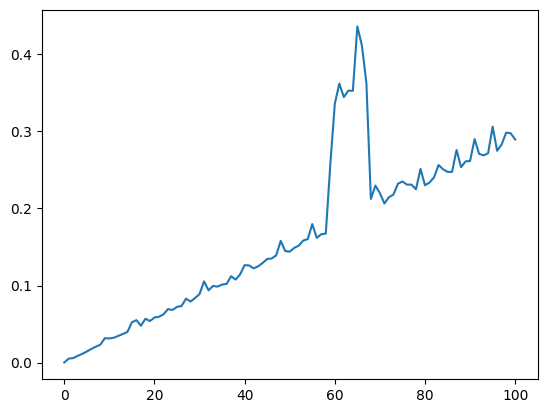

In [12]:
tempo1_n = []
for n in tqdm(range(101)):
  comeco = time.time()
  tempo = bin(n, 0.75, 1000)
  final = time.time()
  tempo1_n.append(final - comeco)

plt.plot(tempo1_n)
plt.show()

100%|██████████| 101/101 [00:01<00:00, 79.33it/s]


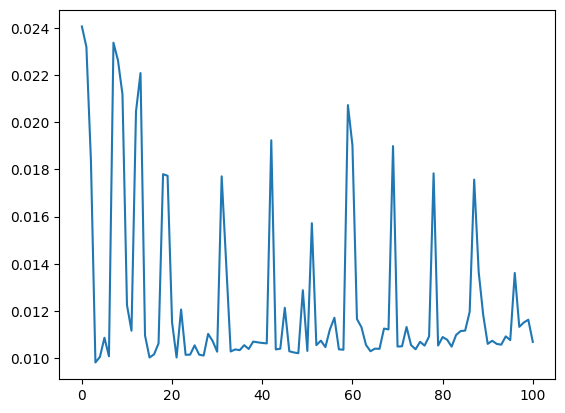

In [13]:
tempo2_n = []
for n in tqdm(range(101)):
  comeco = time.time()
  tempo = binomial_otimizada(n, 0.75, 1000)
  final = time.time()
  tempo2_n.append(final - comeco)

plt.plot(tempo2_n)
plt.show()


100%|██████████| 101/101 [00:01<00:00, 54.41it/s]


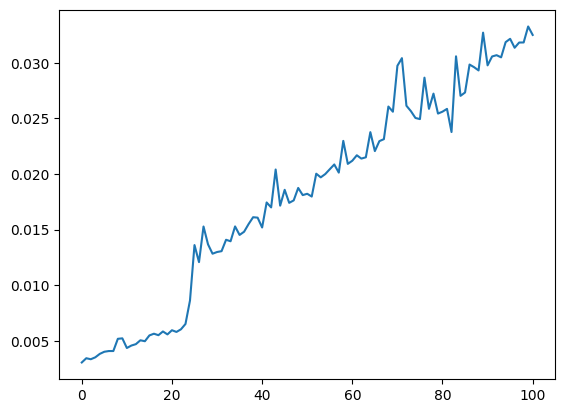

In [14]:
tempo3_n = []
for n in tqdm(range(101)):
  comeco = time.time()
  tempo = binomial_recursiva(n, 0.75, 1000)
  final = time.time()
  tempo3_n.append(final-comeco)

plt.plot(tempo3_n)
plt.show()

In [15]:
medias_n = {
    "Bin": np.mean(tempo1_n),
    "Bin Otimizada": np.mean(tempo2_n),
    "Bin Recursiva": np.mean(tempo3_n)
}
print(medias_n) # Média do tempo de execução dos metodos conforme n varia

{'Bin': np.float64(0.16456897423999145), 'Bin Otimizada': np.float64(0.012479328873133895), 'Bin Recursiva': np.float64(0.018247729480856716)}


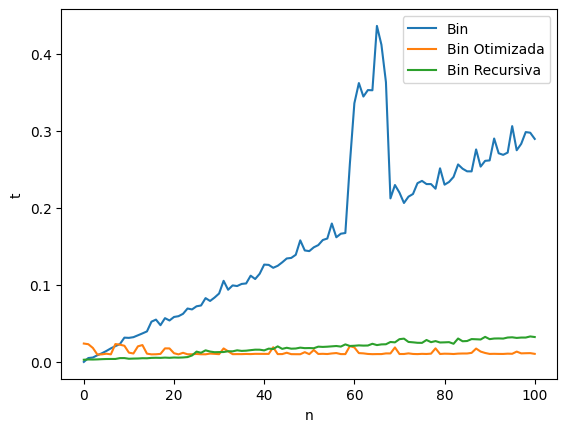

In [16]:
plt.plot(tempo1_n, label="Bin")
plt.plot(tempo2_n, label="Bin Otimizada")
plt.plot(tempo3_n, label="Bin Recursiva")

plt.ylabel("t")
plt.xlabel("n")

plt.legend()
plt.show()

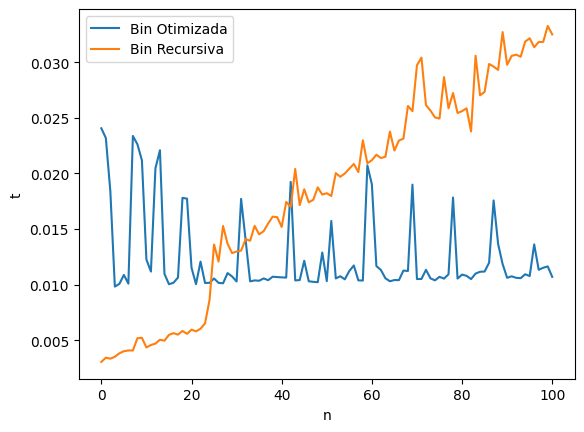

In [17]:
plt.plot(tempo2_n, label="Bin Otimizada")
plt.plot(tempo3_n, label="Bin Recursiva")

plt.ylabel("t")
plt.xlabel("n")

plt.legend()
plt.show()